In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from collections import Counter
import re
import time

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence

from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

torch.manual_seed(42)
device = 'cuda' if torch.cuda.is_available() else 'cpu'

print(f"PyTorch: {torch.__version__}")
print(f"Device: {device}")

PyTorch: 2.10.0+cu128
Device: cuda


In [2]:
"""
RNN: RECURRENT NEURAL NETWORK
==============================

Key idea: Hidden state carries information through time.

At each time step t:
  h_t = tanh(W_hh * h_{t-1} + W_xh * x_t + b)

Unrolled view:

  x_1       x_2       x_3       x_4
   ↓         ↓         ↓         ↓
┌─────┐   ┌─────┐   ┌─────┐   ┌─────┐
│ RNN │──►│ RNN │──►│ RNN │──►│ RNN │──► output
└─────┘   └─────┘   └─────┘   └─────┘
   │         │         │         │
   └─── h_1 ─┴─── h_2 ─┴─── h_3 ─┴─── h_4
         (hidden states carry memory)

For text: "I love this movie"
  x_1 = "I"
  x_2 = "love"
  x_3 = "this"
  x_4 = "movie"
  → Use final h_4 for classification
"""

'\nRNN: RECURRENT NEURAL NETWORK\n==============================\n\nKey idea: Hidden state carries information through time.\n\nAt each time step t:\n  h_t = tanh(W_hh * h_{t-1} + W_xh * x_t + b)\n\nUnrolled view:\n\n  x_1       x_2       x_3       x_4\n   ↓         ↓         ↓         ↓\n┌─────┐   ┌─────┐   ┌─────┐   ┌─────┐\n│ RNN │──►│ RNN │──►│ RNN │──►│ RNN │──► output\n└─────┘   └─────┘   └─────┘   └─────┘\n   │         │         │         │\n   └─── h_1 ─┴─── h_2 ─┴─── h_3 ─┴─── h_4\n         (hidden states carry memory)\n\nFor text: "I love this movie"\n  x_1 = "I"\n  x_2 = "love"\n  x_3 = "this"\n  x_4 = "movie"\n  → Use final h_4 for classification\n'

In [3]:
"""
VANISHING GRADIENT PROBLEM
===========================

In long sequences, gradients shrink exponentially during backprop.

Why? Chain rule multiplication:
  ∂L/∂h_1 = ∂L/∂h_T × ∂h_T/∂h_{T-1} × ... × ∂h_2/∂h_1

If each gradient < 1:
  0.5 × 0.5 × 0.5 × 0.5 = 0.0625  (after just 4 steps!)

Result:
  • Early words get tiny gradients
  • Network forgets long-range dependencies
  • "The movie, despite ..., was good" → "good" dominates

         Gradient magnitude
  h_1    █████████████████████  (we want this)
  h_1    █                       (we get this)

SOLUTION: LSTM and GRU
  • Gates control information flow
  • Additive connections (not just multiplicative)
  • Gradients can flow unchanged through time
"""

'\nVANISHING GRADIENT PROBLEM\n===========================\n\nIn long sequences, gradients shrink exponentially during backprop.\n\nWhy? Chain rule multiplication:\n  ∂L/∂h_1 = ∂L/∂h_T × ∂h_T/∂h_{T-1} × ... × ∂h_2/∂h_1\n\nIf each gradient < 1:\n  0.5 × 0.5 × 0.5 × 0.5 = 0.0625  (after just 4 steps!)\n\nResult:\n  • Early words get tiny gradients\n  • Network forgets long-range dependencies\n  • "The movie, despite ..., was good" → "good" dominates\n\n         Gradient magnitude\n  h_1    █████████████████████  (we want this)\n  h_1    █                       (we get this)\n\nSOLUTION: LSTM and GRU\n  • Gates control information flow\n  • Additive connections (not just multiplicative)\n  • Gradients can flow unchanged through time\n'

In [4]:
"""
LSTM: LONG SHORT-TERM MEMORY
=============================

Key idea: Add a CELL STATE (c_t) that flows through time.

Three gates control information flow:

1. FORGET GATE (f_t)
   "What should I forget from cell state?"
   f_t = σ(W_f · [h_{t-1}, x_t] + b_f)

2. INPUT GATE (i_t)
   "What new info should I add?"
   i_t = σ(W_i · [h_{t-1}, x_t] + b_i)
   c̃_t = tanh(W_c · [h_{t-1}, x_t] + b_c)  # Candidate

3. OUTPUT GATE (o_t)
   "What should I output?"
   o_t = σ(W_o · [h_{t-1}, x_t] + b_o)

Update equations:
   c_t = f_t ⊙ c_{t-1} + i_t ⊙ c̃_t   # Cell state
   h_t = o_t ⊙ tanh(c_t)              # Hidden state

                    c_{t-1}
                       │
         ┌─────────────┼─────────────┐
         │             │             │
         ▼             ▼             ▼
      ┌─────┐      ┌─────┐      ┌─────┐
      │  ×  │◄─f_t │  +  │◄─i_t │tanh │
      └──┬──┘      └──┬──┘      └──┬──┘
         │             │             │
         └─────────────┼─────────────┘
                       │
                       ▼ c_t
                   ┌─────┐
                   │  ×  │◄─o_t
                   └──┬──┘
                      │
                      ▼ h_t
"""

'\nLSTM: LONG SHORT-TERM MEMORY\n=============================\n\nKey idea: Add a CELL STATE (c_t) that flows through time.\n\nThree gates control information flow:\n\n1. FORGET GATE (f_t)\n   "What should I forget from cell state?"\n   f_t = σ(W_f · [h_{t-1}, x_t] + b_f)\n\n2. INPUT GATE (i_t)\n   "What new info should I add?"\n   i_t = σ(W_i · [h_{t-1}, x_t] + b_i)\n   c̃_t = tanh(W_c · [h_{t-1}, x_t] + b_c)  # Candidate\n\n3. OUTPUT GATE (o_t)\n   "What should I output?"\n   o_t = σ(W_o · [h_{t-1}, x_t] + b_o)\n\nUpdate equations:\n   c_t = f_t ⊙ c_{t-1} + i_t ⊙ c̃_t   # Cell state\n   h_t = o_t ⊙ tanh(c_t)              # Hidden state\n\n                    c_{t-1}\n                       │\n         ┌─────────────┼─────────────┐\n         │             │             │\n         ▼             ▼             ▼\n      ┌─────┐      ┌─────┐      ┌─────┐\n      │  ×  │◄─f_t │  +  │◄─i_t │tanh │\n      └──┬──┘      └──┬──┘      └──┬──┘\n         │             │             │\n         └───

In [5]:
"""
GRU: GATED RECURRENT UNIT
==========================

Simpler than LSTM (2 gates instead of 3).

Two gates:

1. RESET GATE (r_t)
   "How much past to forget?"
   r_t = σ(W_r · [h_{t-1}, x_t])

2. UPDATE GATE (z_t)
   "How much to update?"
   z_t = σ(W_z · [h_{t-1}, x_t])

Update:
   h̃_t = tanh(W · [r_t ⊙ h_{t-1}, x_t])  # Candidate
   h_t = (1 - z_t) ⊙ h_{t-1} + z_t ⊙ h̃_t

LSTM vs GRU:
┌─────────────┬────────────────┬────────────────┐
│ Aspect      │ LSTM           │ GRU            │
├─────────────┼────────────────┼────────────────┤
│ Gates       │ 3              │ 2              │
│ States      │ h_t, c_t       │ h_t only       │
│ Parameters  │ More           │ Fewer          │
│ Speed       │ Slower         │ Faster         │
│ Performance │ Often better   │ Competitive    │
└─────────────┴────────────────┴────────────────┘

Rule of thumb:
  • Try GRU first (faster)
  • Use LSTM if GRU underfits
"""

'\nGRU: GATED RECURRENT UNIT\n==========================\n\nSimpler than LSTM (2 gates instead of 3).\n\nTwo gates:\n\n1. RESET GATE (r_t)\n   "How much past to forget?"\n   r_t = σ(W_r · [h_{t-1}, x_t])\n\n2. UPDATE GATE (z_t)\n   "How much to update?"\n   z_t = σ(W_z · [h_{t-1}, x_t])\n\nUpdate:\n   h̃_t = tanh(W · [r_t ⊙ h_{t-1}, x_t])  # Candidate\n   h_t = (1 - z_t) ⊙ h_{t-1} + z_t ⊙ h̃_t\n\nLSTM vs GRU:\n┌─────────────┬────────────────┬────────────────┐\n│ Aspect      │ LSTM           │ GRU            │\n├─────────────┼────────────────┼────────────────┤\n│ Gates       │ 3              │ 2              │\n│ States      │ h_t, c_t       │ h_t only       │\n│ Parameters  │ More           │ Fewer          │\n│ Speed       │ Slower         │ Faster         │\n│ Performance │ Often better   │ Competitive    │\n└─────────────┴────────────────┴────────────────┘\n\nRule of thumb:\n  • Try GRU first (faster)\n  • Use LSTM if GRU underfits\n'

In [6]:
!pip install datasets -q
from datasets import load_dataset

dataset = load_dataset('ag_news')
print(dataset)

README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/18.6M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/1.23M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/120000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/7600 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 120000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 7600
    })
})


In [7]:
train_data = dataset['train']
test_data = dataset['test']
print(f"Train data: {len(train_data)}")
print(f"Test data: {len(test_data)}")

class_names = ['World', 'Sports', 'Business', 'Sci/Tech']
print(f"Class names: {class_names}")

Train data: 120000
Test data: 7600
Class names: ['World', 'Sports', 'Business', 'Sci/Tech']


In [8]:
print("sample articels:")
for i in range(5):
  idx = i * 1000
  text = train_data[idx]['text'][:150] + "..."
  label = class_names[train_data[idx]['label']]
  print(f"\n[{label}]")
  print(f"\n{text}")

sample articels:

[Business]

Wall St. Bears Claw Back Into the Black (Reuters) Reuters - Short-sellers, Wall Street's dwindling\band of ultra-cynics, are seeing green again....

[Sci/Tech]

European Union Extends Microsoft-Time Warner Review BRUSSELS, Belgium (AP) -- European antitrust regulators said Monday they have extended their revie...

[Business]

Applied Materials Reports Profit in 3Q Applied Materials Inc., the world #39;s largest supplier of machines that make computer chips, Tuesday said sur...

[Sci/Tech]

Venus: Inhabited World? by Harry Bortman    In part 1 of this interview with Astrobiology Magazine editor Henry Bortman, planetary scientist David Gri...

[Sci/Tech]

Court Deals Blow to Movie Studios (Reuters) Reuters - A federal appeals court on Thursday\delivered a stinging blow to the anti-piracy efforts of majo...


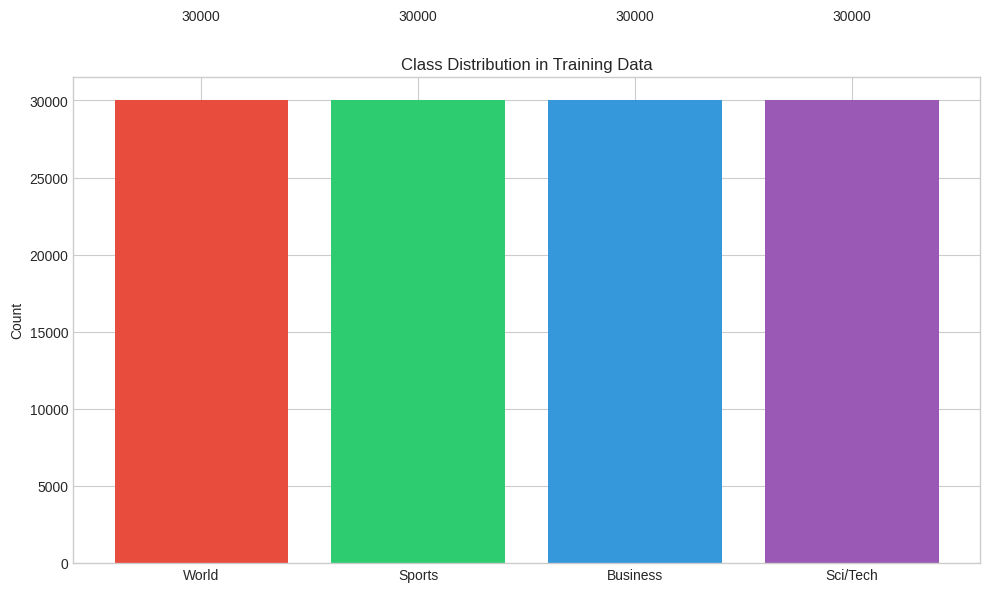

In [9]:
#Class distributionn
train_labels = [x['label'] for x in train_data]
label_counts = Counter(train_labels)

plt.figure(figsize=(10, 6))
colors = ['#e74c3c', '#2ecc71', '#3498db', '#9b59b6']
plt.bar(class_names, [label_counts[i] for i in range(4)], color=colors)
plt.ylabel('Count')
plt.title('Class Distribution in Training Data')
for i, v in enumerate([label_counts[i] for i in range(4)]):
  plt.text(i, v + 5000, str(v), ha='center', va='bottom')
plt.tight_layout()
plt.show()

Text  Preprocessing & Vocabulary

In [10]:
#Simple tokenizer
def tokenize(text):
  text = text.lower()
  text  = re.sub(r'[^a-zA-Z\s]', '', text)    #removing non-letter
  tokens = text.split()
  return tokens

sample = "The Three Studies are generally considered Bacon's first mature piece"
print(f"Original text: {sample}")
print(f"Tokenized text: {tokenize(sample)}")

Original text: The Three Studies are generally considered Bacon's first mature piece
Tokenized text: ['the', 'three', 'studies', 'are', 'generally', 'considered', 'bacons', 'first', 'mature', 'piece']


In [11]:
#Building Vocabulary
word_counts = Counter()
for item in train_data:
  tokens = tokenize(item['text'])
  word_counts.update(tokens)

print(f"Total unique tokens: {len(word_counts)}")
print(f"Most common tokens: {word_counts.most_common(10)}")

Total unique tokens: 91343
Most common tokens: [('the', 203591), ('to', 119170), ('a', 107877), ('of', 97952), ('in', 95476), ('and', 68888), ('on', 56521), ('for', 50240), ('s', 32084), ('that', 27747)]


In [12]:
#Creating a vocab with special tokens
VOCAB_SIZE = 25000
MIN_FREQ = 2

#Special tokkens
PAD_TOKEN = '<PAD>'
UNK_TOKEN = '<UNK>'

#filtering by freq.
vocab_words = [word for word, count in word_counts.most_common(VOCAB_SIZE) if count >= MIN_FREQ]

#create word to index mapping
word2idx = {PAD_TOKEN: 0, UNK_TOKEN: 1}
for i, word in enumerate(vocab_words):
  word2idx[word] = i + 2
idx2word = {v: k for k, v in word2idx.items()}

VOCAB_SIZE = len(word2idx)
print(f"Vocabulary size: {VOCAB_SIZE}")


Vocabulary size: 25002


In [13]:
#Converting text to indices
def text_to_indices(text, word2idx, max_len=100):
  tokens = tokenize(text)
  indices = [word2idx.get(token, word2idx[UNK_TOKEN]) for token in tokens]

  #truncate or pad
  if len(indices) > max_len:
    indices = indices[:max_len]
  return indices

#Test
sample_indices = text_to_indices(sample, word2idx)
print(f"Text: {sample}")
print(f"Indices: {sample_indices}")
print(f"Back to words: {[idx2word[i] for i in sample_indices]}")

Text: The Three Studies are generally considered Bacon's first mature piece
Indices: [2, 82, 4748, 35, 6749, 2553, 1, 38, 12259, 3544]
Back to words: ['the', 'three', 'studies', 'are', 'generally', 'considered', '<UNK>', 'first', 'mature', 'piece']


Word Embeddings

In [14]:
"""
WORD EMBEDDINGS
================

Problem: Words are discrete symbols.
  "cat" = 42
  "dog" = 87
  → 42 and 87 have no semantic meaning!

Solution: Map words to dense vectors.
  "cat" → [0.2, -0.5, 0.1, ...]
  "dog" → [0.3, -0.4, 0.2, ...]
  → Similar words have similar vectors!

nn.Embedding:
  • Lookup table: vocab_size × embedding_dim
  • Learned during training
  • Or use pretrained (Word2Vec, GloVe)

  word_idx ───► ┌─────────────┐ ───► embedding vector
                │  Embedding  │
                │   Matrix    │
                └─────────────┘
                 (25000 × 128)
"""

'\nWORD EMBEDDINGS\n================\n\nProblem: Words are discrete symbols.\n  "cat" = 42\n  "dog" = 87\n  → 42 and 87 have no semantic meaning!\n\nSolution: Map words to dense vectors.\n  "cat" → [0.2, -0.5, 0.1, ...]\n  "dog" → [0.3, -0.4, 0.2, ...]\n  → Similar words have similar vectors!\n\nnn.Embedding:\n  • Lookup table: vocab_size × embedding_dim\n  • Learned during training\n  • Or use pretrained (Word2Vec, GloVe)\n\n  word_idx ───► ┌─────────────┐ ───► embedding vector\n                │  Embedding  │\n                │   Matrix    │\n                └─────────────┘\n                 (25000 × 128)\n'

Creating Dataset & DataLoaders

In [15]:
class AGNewsDataset(Dataset):
  def __init__(self, data, word2idx, max_len=100):
    self.data = data
    self.word2idx = word2idx
    self.max_len = max_len
  def __len__(self):
    return len(self.data)

  def __getitem__(self, idx):
    text = self.data[idx]['text']
    label = self.data[idx]['label']

    indices = text_to_indices(text, self.word2idx, self.max_len)

    return {
        'inputs_ids': torch.tensor(indices, dtype=torch.long),
        'label': torch.tensor(label, dtype=torch.long),
        'length': len(indices)
    }
print("Dataset class defined")

Dataset class defined


In [16]:
def collate_fn(batch):
  input_ids = [item['inputs_ids'] for item in batch]
  labels =  torch.stack([item['label'] for item in batch])
  lengths = torch.tensor([item['length'] for item in batch])

  #pad seqeunces
  input_ids_padded = pad_sequence(input_ids, batch_first=True, padding_value=0)

  return {
      'inputs_ids': input_ids_padded,
      'labels': labels,
      'lengths': lengths
  }

print('COllate function defined')

COllate function defined


In [17]:
from huggingface_hub import batch_bucket_files
#creating dataset and dataloaders
MAX_LEN = 100
BATCH_SIZE = 64

train_dataset = AGNewsDataset(train_data, word2idx, MAX_LEN)
test_dataset = AGNewsDataset(test_data, word2idx, MAX_LEN)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn, num_workers=4)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn, num_workers=4)

print(f"Train dataloader: {len(train_loader)} batches")
print(f"Test dataloader: {len(test_loader)} batches")

#Check a batch
batch = next(iter(train_loader))
print(f"Batch shapes:")
print(f"Inputs: {batch['inputs_ids'].shape}")
print(f"Labels: {batch['labels'].shape}")

Train dataloader: 1875 batches
Test dataloader: 119 batches
Batch shapes:
Inputs: torch.Size([64, 68])
Labels: torch.Size([64])


LSTM Classifier

In [18]:
class LSTMClassifier(nn.Module):
  def __init__(self, vocab_size, embedding_dim, hidden_dim, output_dim, n_layers=2, dropout=0.5, bidirectional=True):
    super().__init__()
    self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)

    self.lstm = nn.LSTM(
        input_size= embedding_dim,
        hidden_size=hidden_dim,
        num_layers=n_layers,
        dropout=dropout if n_layers > 1 else 0,
        bidirectional=bidirectional,
        batch_first=True
    )

    #Bidirectional doubles hidden size
    lstm_output_dim = hidden_dim  * 2 if bidirectional else hidden_dim

    self.fc = nn.Sequential(
        nn.Linear(lstm_output_dim, hidden_dim),
        nn.ReLU(),
        nn.Dropout(dropout),
        nn.Linear(hidden_dim, output_dim)
    )

    self.dropout = nn.Dropout(dropout)

  def forward(self, input_ids):
    embedded = self.dropout(self.embedding(input_ids))  # (batch, seq_len, embed_dim)

    # LSTM
    lstm_out, (hidden, cell) = self.lstm(embedded)
    #lstm_out: (batch, seq_len, hidden_dim * 2)
    # hidden: (n_layers * 2, batch, hidden_dim)

    #Usinfg the last hidden state
    if self.lstm.bidirectional:
      hidden_cat = torch.cat((hidden[-2], hidden[-1]), dim=1)
    else:
      hidden_cat = hidden[-1]

    #Classifying
    output = self.fc(hidden_cat)

    return output
print("LSTM Classifier defined")


LSTM Classifier defined


In [19]:
EMBEDDING_DIM = 128
HIDDEN_DIM = 256
OUTPUT_DIM = 4
N_LAYERS = 2
DROPOUT = 0.5

model = LSTMClassifier(
    vocab_size=VOCAB_SIZE,
    embedding_dim=EMBEDDING_DIM,
    hidden_dim=HIDDEN_DIM,
    output_dim=OUTPUT_DIM,
    n_layers=N_LAYERS,
    dropout=DROPOUT,
    bidirectional=True
)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total parameters: {total_params}")
print(f"Trainable parameters: {trainable_params}")

Total parameters: 5700100
Trainable parameters: 5700100


In [20]:
model.to(device)
#Testing the forward pass
sample_batch = batch['inputs_ids'].to(device)
output = model(sample_batch)
print(f"Input: {sample_batch.shape}")
print(f"Output: {output.shape}")

Input: torch.Size([64, 68])
Output: torch.Size([64, 4])


In [21]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=2, factor=0.5)

In [22]:
def train_epoch(model, loader, criterion, optimizer):
  model.train()
  total_loss = 0
  correct = 0
  total = 0

  for batch in loader:
    input_ids = batch['inputs_ids'].to(device)
    labels = batch['labels'].to(device)

    optimizer.zero_grad()
    outputs = model(input_ids)
    loss = criterion(outputs, labels)
    loss.backward()

    #gradient clipping
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

    optimizer.step()

    total_loss += loss.item()
    _, predicted = torch.max(outputs,  1)
    correct += (predicted == labels).sum().item()
    total += labels.size(0)

  return total_loss / len(loader), correct / total

def evaluate(model, loader, criterion):
  model.eval()
  total_loss = 0
  correct = 0
  total = 0

  with torch.no_grad():
    for batch in loader:
      input_ids = batch['inputs_ids'].to(device)
      labels = batch['labels'].to(device)

      outputs = model(input_ids)
      loss = criterion(outputs, labels)

      total_loss += loss.item()
      _, predicted = torch.max(outputs, 1)
      correct += (predicted == labels).sum().item()
      total += labels.size(0)

  return total_loss / len(loader), correct / total
print("Training func defined")

Training func defined


In [23]:
EPOCHS = 10

history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
best_val_acc = 0.0 # Initialize best_val_acc

for epoch in range(EPOCHS):
  start_time = time.time()
  train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer)
  val_loss, val_acc = evaluate(model, test_loader, criterion)
  end_time = time.time()
  elapsed = end_time - start_time

  scheduler.step(val_loss)

  history['train_loss'].append(train_loss)
  history['train_acc'].append(train_acc)
  history['val_loss'].append(val_loss)
  history['val_acc'].append(val_acc)

  # Save best model
  if val_acc > best_val_acc:
      best_val_acc = val_acc
      torch.save(model.state_dict(), 'best_lstm_model.pt')
      marker = '(saved)'
  else:
      marker = ''

  print(f"Epoch {epoch+1:2d}/{EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2%} | "
        f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2%} | "
        f"Time: {elapsed:.1f}s{marker}")

print(f"\nBest validation accuracy: {best_val_acc:.2%}")

Epoch  1/10 | Train Loss: 0.6629 | Train Acc: 74.92% | Val Loss: 0.3955 | Val Acc: 87.05% | Time: 60.6s(saved)
Epoch  2/10 | Train Loss: 0.3739 | Train Acc: 87.20% | Val Loss: 0.2940 | Val Acc: 90.36% | Time: 64.4s(saved)
Epoch  3/10 | Train Loss: 0.3062 | Train Acc: 89.67% | Val Loss: 0.2674 | Val Acc: 91.13% | Time: 63.5s(saved)
Epoch  4/10 | Train Loss: 0.2681 | Train Acc: 90.86% | Val Loss: 0.2476 | Val Acc: 91.42% | Time: 63.5s(saved)
Epoch  5/10 | Train Loss: 0.2437 | Train Acc: 91.71% | Val Loss: 0.2451 | Val Acc: 92.16% | Time: 63.6s(saved)
Epoch  6/10 | Train Loss: 0.2238 | Train Acc: 92.33% | Val Loss: 0.2311 | Val Acc: 92.22% | Time: 63.7s(saved)
Epoch  7/10 | Train Loss: 0.2091 | Train Acc: 92.73% | Val Loss: 0.2661 | Val Acc: 92.28% | Time: 63.9s(saved)
Epoch  8/10 | Train Loss: 0.1972 | Train Acc: 93.21% | Val Loss: 0.2331 | Val Acc: 92.37% | Time: 63.7s(saved)
Epoch  9/10 | Train Loss: 0.1882 | Train Acc: 93.46% | Val Loss: 0.2226 | Val Acc: 92.84% | Time: 63.6s(saved)
E

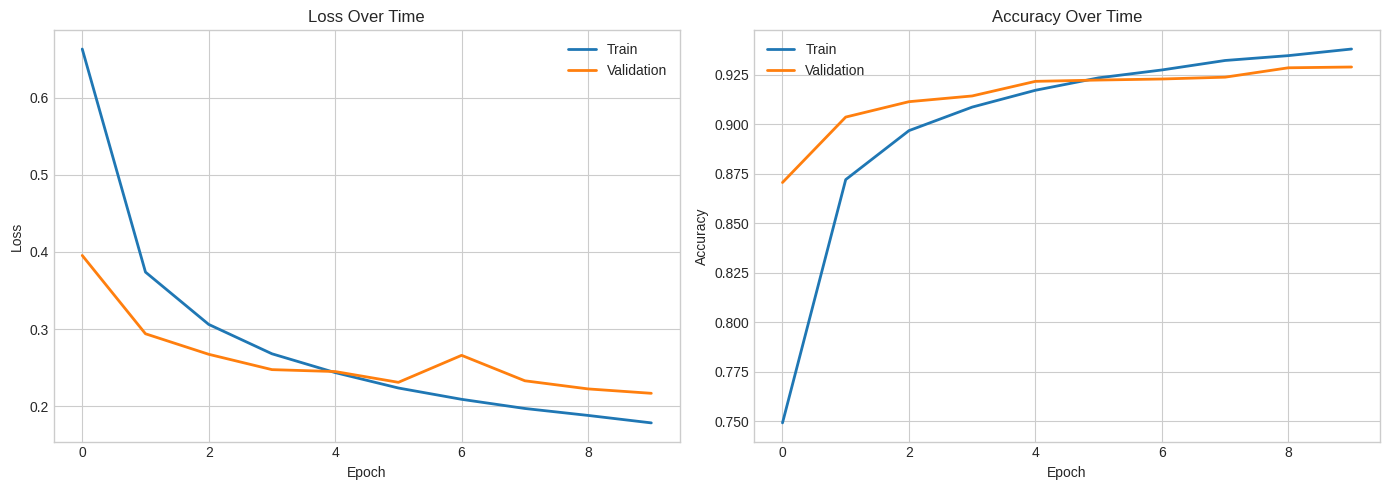

In [24]:
# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
axes[0].plot(history['train_loss'], label='Train', linewidth=2)
axes[0].plot(history['val_loss'], label='Validation', linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Loss Over Time')
axes[0].legend()
axes[0].grid(True)

# Accuracy
axes[1].plot(history['train_acc'], label='Train', linewidth=2)
axes[1].plot(history['val_acc'], label='Validation', linewidth=2)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Accuracy Over Time')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

Evaluating on the test set

In [25]:
model.load_state_dict(torch.load('best_lstm_model.pt'))
print("Loaded best model")

Loaded best model


In [27]:
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for batch in test_loader:
        input_ids = batch['inputs_ids'].to(device)
        labels = batch['labels']

        outputs = model(input_ids)
        _, predicted = torch.max(outputs, 1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

In [28]:
# Classification report
print("\nClassification Report:")
print("="*60)
print(classification_report(all_labels, all_preds, target_names=class_names))


Classification Report:
              precision    recall  f1-score   support

       World       0.94      0.92      0.93      1900
      Sports       0.97      0.98      0.98      1900
    Business       0.89      0.90      0.90      1900
    Sci/Tech       0.90      0.91      0.91      1900

    accuracy                           0.93      7600
   macro avg       0.93      0.93      0.93      7600
weighted avg       0.93      0.93      0.93      7600



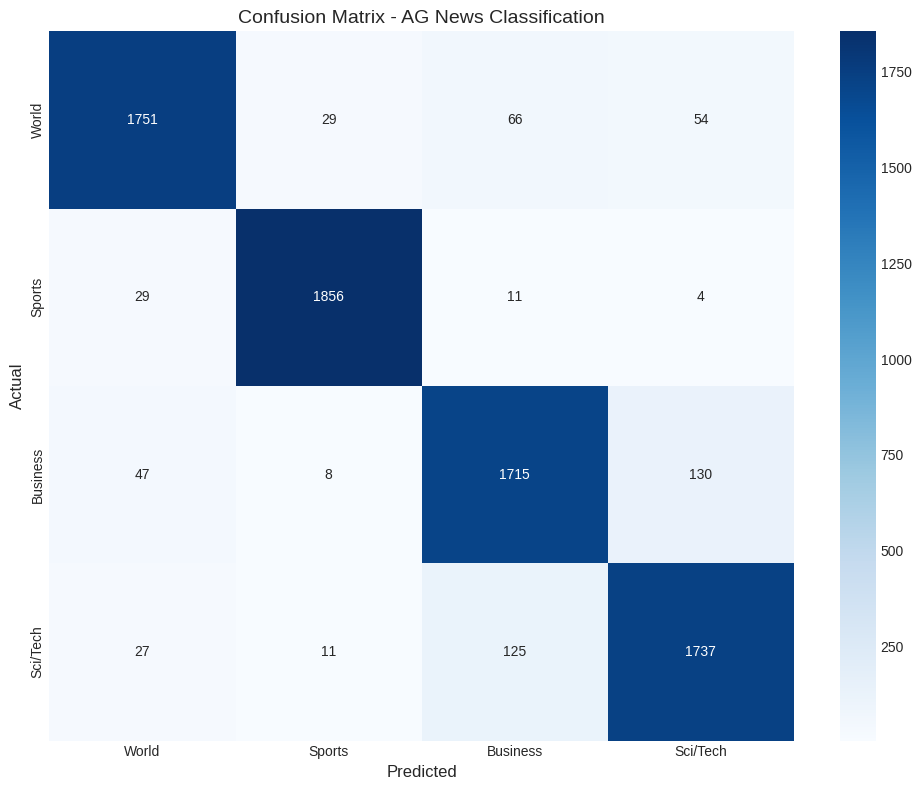

In [29]:
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.title('Confusion Matrix - AG News Classification', fontsize=14)
plt.tight_layout()
plt.show()

Testing on a custom set

In [30]:
# Predict function
def predict_text(text, model, word2idx, class_names):
    model.eval()

    indices = text_to_indices(text, word2idx, MAX_LEN)
    input_tensor = torch.tensor([indices], dtype=torch.long).to(device)

    with torch.no_grad():
        output = model(input_tensor)
        probs = torch.softmax(output, dim=1)[0]
        pred_idx = torch.argmax(probs).item()

    return class_names[pred_idx], probs.cpu().numpy()

print("Prediction function ready")

Prediction function ready


In [31]:
# Test on custom headlines
test_headlines = [
    "Apple announces new iPhone with revolutionary AI features",
    "Lakers defeat Celtics in thrilling overtime victory",
    "Stock market reaches all-time high amid economic recovery",
    "UN Security Council meets to discuss Middle East crisis",
    "Scientists discover New species in Amazon rainforest",
    "Microsoft acquires gaming company for 50 billion dollars",
]

print("Custom Text Predictions:")
print("="*60)

for headline in test_headlines:
    pred_class, probs = predict_text(headline, model, word2idx, class_names)

    print(f"\n\"{headline}\"")
    print(f"  → Predicted: {pred_class}")
    print(f"  → Probabilities: ", end="")
    for i, (cls, prob) in enumerate(zip(class_names, probs)):
        print(f"{cls}: {prob:.1%}", end="  ")
    print()

Custom Text Predictions:

"Apple announces new iPhone with revolutionary AI features"
  → Predicted: Sci/Tech
  → Probabilities: World: 0.3%  Sports: 0.0%  Business: 1.8%  Sci/Tech: 97.9%  

"Lakers defeat Celtics in thrilling overtime victory"
  → Predicted: World
  → Probabilities: World: 88.9%  Sports: 9.2%  Business: 1.6%  Sci/Tech: 0.3%  

"Stock market reaches all-time high amid economic recovery"
  → Predicted: Business
  → Probabilities: World: 38.5%  Sports: 0.2%  Business: 58.9%  Sci/Tech: 2.4%  

"UN Security Council meets to discuss Middle East crisis"
  → Predicted: World
  → Probabilities: World: 96.4%  Sports: 0.0%  Business: 0.4%  Sci/Tech: 3.2%  

"Scientists discover New species in Amazon rainforest"
  → Predicted: Sci/Tech
  → Probabilities: World: 2.3%  Sports: 0.0%  Business: 0.0%  Sci/Tech: 97.6%  

"Microsoft acquires gaming company for 50 billion dollars"
  → Predicted: Sci/Tech
  → Probabilities: World: 0.0%  Sports: 0.0%  Business: 1.4%  Sci/Tech: 98.6%  



Try your own headlines!

Enter a news headline: France to Offer Loans to Small Businesses Hit by Fuel Costs

  Predicted category: World


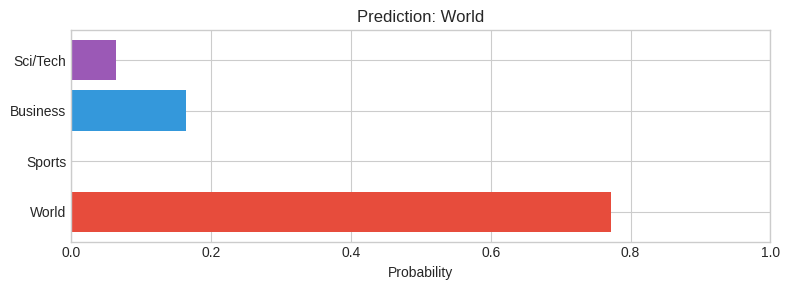

In [34]:
# Interactive prediction
print("\nTry your own headlines!")
print("="*60)

text = input("\nEnter a news headline: ")

pred_class, probs = predict_text(text, model, word2idx, class_names)
print(f"\n  Predicted category: {pred_class}")

# Visualize
plt.figure(figsize=(8, 3))
colors = ['#e74c3c', '#2ecc71', '#3498db', '#9b59b6']
plt.barh(class_names, probs, color=colors)
plt.xlabel('Probability')
plt.title(f'Prediction: {pred_class}')
plt.xlim(0, 1)
plt.tight_layout()
plt.show()

In [35]:
import os
import pickle

from google.colab import drive
drive.mount('/content/drive')

save_path = '/content/drive/MyDrive/100-days-of-ml/phase-3-deep-learning/day-50-rnn-lstm'
os.makedirs(save_path, exist_ok=True)

# Save model
torch.save(model.state_dict(), f'{save_path}/lstm_agnews.pt')

# Save vocabulary
with open(f'{save_path}/word2idx.pkl', 'wb') as f:
    pickle.dump(word2idx, f)

print(f"\nSaved to: {save_path}")
print("Files:")
print("  - lstm_agnews.pt (model weights)")
print("  - word2idx.pkl (vocabulary)")

Mounted at /content/drive

Saved to: /content/drive/MyDrive/100-days-of-ml/phase-3-deep-learning/day-50-rnn-lstm
Files:
  - lstm_agnews.pt (model weights)
  - word2idx.pkl (vocabulary)



## Summary

### Concepts Covered

| Concept | Description |
|---------|-------------|
| RNN | Recurrent unit with hidden state |
| Vanishing Gradients | Why vanilla RNNs fail |
| LSTM | 3 gates (forget, input, output) + cell state |
| GRU | 2 gates (reset, update), simpler |
| Embeddings | Words → dense vectors |
| Bidirectional | Process forward AND backward |

### Model Architecture

```
Input (word indices)
    ↓
Embedding (25K × 128)
    ↓
Bidirectional LSTM (2 layers, 256 hidden)
    ↓
FC (512 → 256 → 4)
    ↓
Softmax → Class
```

### Results

| Metric | Score |
|--------|-------|
| Test Accuracy | ~90%+ |
| Classes | World, Sports, Business, Sci/Tech |

